# Instituto Tecnológico y de Estuidos Superiores de Monterrey Campus Querétaro
## Arturo Sánchez Rodríguez | A01275427
# OnePiece


In [3]:
#Importar las librerías que vamos a utilizar en el proyecto de clasificación de imágenes
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras import models, layers

In [4]:

onePiece_data = "OnePiece/Data/Data" #Definimos la ruta de nuestro dataset para luego poder llamarlo
print(os.listdir("OnePiece/Data/Data/")[::]) #Vemos las clases que tenemos en nuestro dataset


['Akainu', '.DS_Store', 'Sanji', 'Jinbei', 'Nami', 'Law', 'Crocodile', 'Mihawk', 'Chopper', 'Zoro', 'Shanks', 'Brook', 'Rayleigh', 'Usopp', 'Kurohige', 'Franky', 'Ace', 'Luffy', 'Robin']


## Aqui lo que tenemos que hacer es convertir las imágenes a números para que la computadora las pueda leer

In [5]:
#A diferencia con el dataset de MNIST que ya tiene las imágenes convertidas en números y listas para ser utilizadas, con nuestro modelo no esta asi entonces como la computadora no puede ver las imágenes tenemos que convertirlos en números.

def cargar_img(path, img_size=(64, 64)):
    images = []
    labels = []

    class_names = sorted([
        clase for clase in os.listdir(path)
        if os.path.isdir(os.path.join(path, clase))
    ])

    for label_index, class_name in enumerate(class_names):
        class_path = os.path.join(path, class_name)
        for file_name in os.listdir(class_path):
            if file_name.lower().endswith((".png", ".jpg", "jpeg")):
                img_path = os.path.join(class_path, file_name)
                img = tf.keras.utils.load_img(img_path, target_size=img_size)
                img_array = tf.keras.utils.img_to_array(img)
                images.append(img_array)
                labels.append(label_index)
    images = np.array(images)
    labels = np.array(labels)

    return images, labels, class_names

images, labels, class_names = cargar_img(onePiece_data)


/Users/arturosr/Library/Python/3.11/lib/python/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


## Imprimimos la forma que tienen las imágenes, sus etiquetas, nombre de las clases y la cantidad de clases que tenemos (Las clases son los personajes en el dataset)

In [6]:
#Imprimimos la forma de las imágenes, etiquetas, nombres de clases y la cantidad de clases para verificar que todo se haya cargado correctamente
print(images.shape)
print(labels.shape)
print(class_names)
print(len(class_names))

(11737, 64, 64, 3)
(11737,)
['Ace', 'Akainu', 'Brook', 'Chopper', 'Crocodile', 'Franky', 'Jinbei', 'Kurohige', 'Law', 'Luffy', 'Mihawk', 'Nami', 'Rayleigh', 'Robin', 'Sanji', 'Shanks', 'Usopp', 'Zoro']
18


## Separamos el dataset en Test y Train

In [7]:
#Separamos el dataset en TRAIN y TEST
train_img, test_img, train_labels, test_labels = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train imágenes:", train_img.shape)
print("Test imágenes:", test_img.shape)
print("Train labels:", train_labels.shape)
print("Test labels:", test_labels.shape)

Train imágenes: (9389, 64, 64, 3)
Test imágenes: (2348, 64, 64, 3)
Train labels: (9389,)
Test labels: (2348,)


## Escalamos las imágenes para que los valores sean entre 0 y 1


In [8]:

def scale_img(train_img, test_img):
    train_img = train_img / 255.
    test_img = test_img / 255.
    return train_img, test_img

In [9]:

train_img, test_img = scale_img(train_img, test_img)

print("train_img.shape:", train_img.shape)
print("test_img.shape:", test_img.shape)
print("train_img.min():", train_img.min(), "train_img.max():", train_img.max())
print("test_img.min():", test_img.min(), "test_img.max():", test_img.max())

train_img.shape: (9389, 64, 64, 3)
test_img.shape: (2348, 64, 64, 3)
train_img.min(): 0.0 train_img.max(): 1.0
test_img.min(): 0.0 test_img.max(): 1.0


## Guardamos las imágenes de test y train en formato .npy para luego pode utilizarlas

In [10]:


np.save("train_img.npy", train_img)
np.save("test_img.npy", test_img)

np.save("train_labels.npy", train_labels)
np.save("test_labels.npy", test_labels)

print("Se guardaron los test y train en formato .npy de manera correcta!")

Se guardaron los test y train en formato .npy de manera correcta!


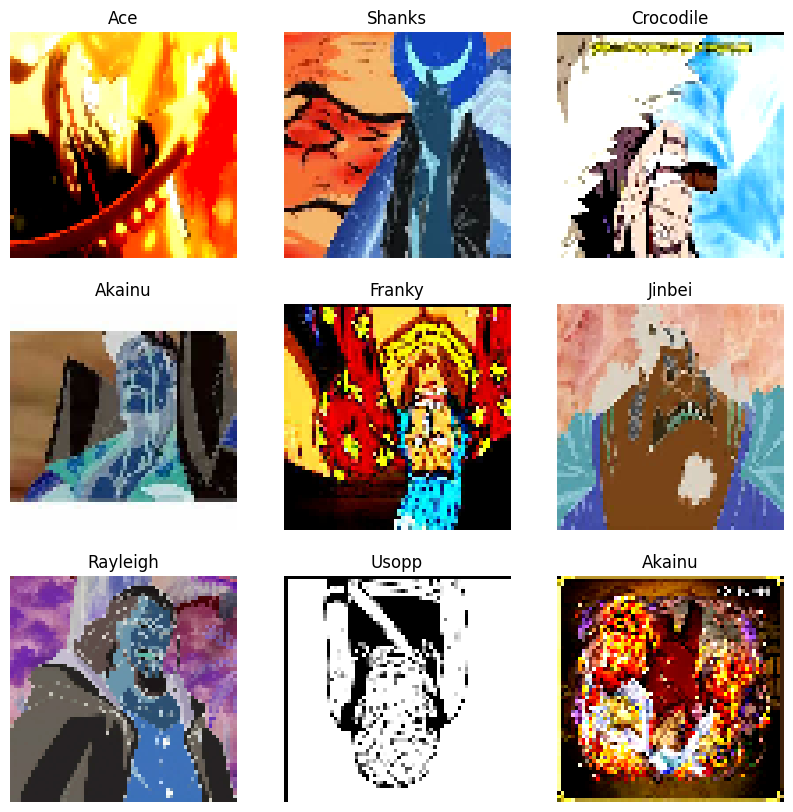

In [11]:
# Visualizar imágenes de ejemplo

import random

plt.figure(figsize=(10,10))

for i in range(9):
    idx = random.randint(0, len(train_img)-1)

    plt.subplot(3,3,i+1)
    plt.imshow(train_img[idx])
    plt.title(class_names[train_labels[idx]])
    plt.axis("off")

plt.show()

# Modelo 1 MLP

In [12]:
#Tenemos que definir cuántas clases tiene nuestro dataset

num_classes = len(class_names)
print("Número de clases:", num_classes)
print("Clases:", class_names)

Número de clases: 18
Clases: ['Ace', 'Akainu', 'Brook', 'Chopper', 'Crocodile', 'Franky', 'Jinbei', 'Kurohige', 'Law', 'Luffy', 'Mihawk', 'Nami', 'Rayleigh', 'Robin', 'Sanji', 'Shanks', 'Usopp', 'Zoro']


In [13]:
#Creamos el modelo de red neuronal tradicional MLP (Multi-layer Perceptron)

def get_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Flatten(input_shape=input_shape),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model = get_model(input_shape=(64, 64, 3), num_classes=num_classes) 
model.summary()

/Users/arturosr/Library/Python/3.11/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,575,314 (6.01 MB)

 Trainable params: 1,575,314 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#Compiamos el modelo 
def compile_model(model):
    model.compile(
        optimizer="adam", #Adam es el algoritmo que modifica los pesos y los ajusta automáticamente
        loss="sparse_categorical_crossentropy", #Función de pérdida para clasificación multiclase
        metrics=["accuracy"] #Métrica para evaluar el rendimiento del modelo
    )

compile_model(model)

In [15]:
#Entrenamos el modelo
def train_model(model, train_img, train_labels):
    history = model.fit(train_img, train_labels, validation_split=0.2, epochs=25)
    return history

history = train_model(model, train_img, train_labels)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0566 - loss: 3.2572 - val_accuracy: 0.0511 - val_loss: 2.8904
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0542 - loss: 2.8906 - val_accuracy: 0.0522 - val_loss: 2.8908
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0559 - loss: 2.8892 - val_accuracy: 0.0522 - val_loss: 2.8908
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0579 - loss: 2.8863 - val_accuracy: 0.0532 - val_loss: 2.8880
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0626 - loss: 2.8813 - val_accuracy: 0.0596 - val_loss: 2.8867
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0616 - loss: 2.8759 - val_accuracy: 0.0591 - val_loss: 2.8842
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0662 - loss: 2.8764 - val_accuracy: 0.0591 - val_loss: 2.8816
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0683 - loss: 2.8689 - val_accuracy: 0.

In [16]:
#Evaluamos el modelo con el set de prueba
test_loss, test_accuracy = model.evaluate(test_img, test_labels)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - accuracy: 0.0711 - loss: 2.9598
Test loss: 2.9598283767700195
Test accuracy: 0.0711243599653244


# Modelo 2 CNN

In [17]:
#Construimos el modelo CNN

def get_modelo_CNN(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(6, kernel_size=3, padding="same", activation="relu", input_shape=input_shape),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model 

model_cnn = get_modelo_CNN(input_shape=(64, 64, 3), num_classes=num_classes)
model_cnn.summary()

/Users/arturosr/Library/Python/3.11/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 6)      │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 24576)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,145,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,148,346 (12.01 MB)

 Trainable params: 3,148,346 (12.01 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Compilamos y entrenamos el modelo CNN

compile_model(model_cnn)
history_cnn = train_model(model_cnn, train_img, train_labels)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1034 - loss: 3.1218 - val_accuracy: 0.1432 - val_loss: 2.7315
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2704 - loss: 2.4053 - val_accuracy: 0.2183 - val_loss: 2.5918
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4986 - loss: 1.7632 - val_accuracy: 0.2141 - val_loss: 2.7072
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6976 - loss: 1.1523 - val_accuracy: 0.2359 - val_loss: 2.8881
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8490 - loss: 0.6618 - val_accuracy: 0.2513 - val_loss: 3.1625
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9388 - loss: 0.3393 - val_accuracy: 0.2354 - val_loss: 3.5256
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9803 - loss: 0.1638 - val_accuracy: 0.2370 - val_loss: 3.8463
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9945 - loss: 0.0798 - val_accuracy: 0.

In [19]:
#Evaluamos el modelo CNN con el set de prueba

test_loss_cnn, test_accuracy_cnn = model_cnn.evaluate(test_img, test_labels)
print("Test loss CNN:", test_loss_cnn)
print("Test accuracy CNN:", test_accuracy_cnn)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2376 - loss: 6.0923
Test loss CNN: 6.092260837554932
Test accuracy CNN: 0.237649068236351


# Modelo 3
## CNN + Data Augmentation

In [20]:
#implementamos data augmentation para mejorar el rendimiento del modelo 2 CNN y evitar overfitting

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    #layers.RandomTranslation(0.1, 0.1),
    #layers.RandomContrast(0.1),
    #layers.RandomFlip("vertical")
])


In [21]:
#Contruimos el modelo 3 (CNN) con data augmentation

def get_modelo_CNN_aug(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,
        layers.Conv2D(6, kernel_size=3, padding="same", activation="relu"),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model 

model_cnn_aug = get_modelo_CNN_aug(input_shape=(64, 64, 3), num_classes=num_classes)
model_cnn_aug.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 6)      │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 24576)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,145,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,148,346 (12.01 MB)

 Trainable params: 3,148,346 (12.01 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#Compilamos y entrenamos el modelo CNN con data augmentation

compile_model(model_cnn_aug)
history_cnn_aug = train_model(model_cnn_aug, train_img, train_labels)


Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0991 - loss: 2.8214 - val_accuracy: 0.1267 - val_loss: 2.7964
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1704 - loss: 2.6448 - val_accuracy: 0.1470 - val_loss: 2.7982
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2201 - loss: 2.5114 - val_accuracy: 0.1550 - val_loss: 2.7309
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2354 - loss: 2.4441 - val_accuracy: 0.2125 - val_loss: 2.5697
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2639 - loss: 2.3650 - val_accuracy: 0.2396 - val_loss: 2.4517
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2769 - loss: 2.3392 - val_accuracy: 0.2311 - val_loss: 2.4795
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2880 - loss: 2.3070 - val_accuracy: 0.2119 - val_loss: 2.6024
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2909 - loss: 2.2698 - val_accuracy: 0.

In [23]:
# Evaluamos el modelo CNN con data augmentation con el set de prueba

test_loss_cnn_aug, test_accuracy_cnn_aug = model_cnn_aug.evaluate(test_img, test_labels)
print("Test loss CNN con data augmentation:", test_loss_cnn_aug)
print("Test accuracy CNN con data augmentation:", test_accuracy_cnn_aug)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3071 - loss: 2.3687
Test loss CNN con data augmentation: 2.3687407970428467
Test accuracy CNN con data augmentation: 0.3070698380470276


In [24]:
# Ver accuracy final de los 3 modelos

#MLP
print(history.history["accuracy"][-1])
print(history.history["val_accuracy"][-1])

#CNN
print(history_cnn.history["accuracy"][-1])
print(history_cnn.history["val_accuracy"][-1])

#CNN con data augmentation
print(history_cnn_aug.history["accuracy"][-1])
print(history_cnn_aug.history["val_accuracy"][-1])


0.08387698233127594
0.07401490956544876
1.0
0.2401490956544876
0.3791772127151489
0.2997870147228241


# Comparando los 3 Modelos base

In [ ]:
import pandas as pd

#Creamos un "DataFrame" para mostrar los resultados de los 3 modelos 
results_baseline = pd.DataFrame({
    "Model": [
        "MLP",
        "CNN",
        "CNN + Data Augmentation"
    ],
    #Resultados de train accuracy
    "Train Accuracy": [
        history.history["accuracy"][-1] * 100,
        history_cnn.history["accuracy"][-1] * 100,
        history_cnn_aug.history["accuracy"][-1] * 100
    ],
    #Resultados de validation accuracy
    "Validation Accuracy": [
        history.history["val_accuracy"][-1] * 100,
        history_cnn.history["val_accuracy"][-1] * 100,
        history_cnn_aug.history["val_accuracy"][-1] * 100
    ],
    #Resultados de test accuracy
    "Test Accuracy": [
        test_accuracy * 100,
        test_accuracy_cnn * 100,
        test_accuracy_cnn_aug * 100
    ]
})

results_baseline

,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,MLP,8.387698,7.401491,7.112436
1,CNN,100.000000,24.014910,23.764907
2,CNN + Data Augmentation,37.917721,29.978701,30.706984
